## 7.11 양자 위상 추정(QPE)을 이용한 전자구조 계산

In [1]:
# Qiskit 라이브러리 임포트
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_state_qsphere, plot_state_city, plot_histogram
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT
from qiskit.quantum_info import partial_trace
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# 양자 위상 추정 회로 정의
n_qubits = 4  # 카운팅 큐비트 수
eigenstate_qubits = 2  # 고유상태 큐비트 수

In [3]:
# QPE용 QuantumCircuit 생성
qc = QuantumCircuit(n_qubits + eigenstate_qubits, n_qubits)

In [4]:
# 카운팅 큐비트에 하다마드 게이트 적용
for i in range(n_qubits):
    qc.h(i)

In [5]:
# 예시 유니타리 연산(Pauli-Z)을 정의하고 제어 유니타리 회전 적용
unitary_gate = QuantumCircuit(eigenstate_qubits)
unitary_gate.cz(0, 1)

In [6]:
# 제어 유니타리 추가 (예: 제어-Z 게이트)
for i in range(n_qubits):
    qc.append(unitary_gate.to_gate().control(), [i] + [j + n_qubits for j in range(eigenstate_qubits)])

In [7]:
# 역 양자 푸리에 변환(QFT) 적용
qc.append(QFT(n_qubits, inverse=True).to_gate(), range(n_qubits))

/sessions/eloquent-vigilant-lovelace/tmp/ipykernel_36/1924421446.py:2: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_qubits, inverse=True).to_gate(), range(n_qubits))


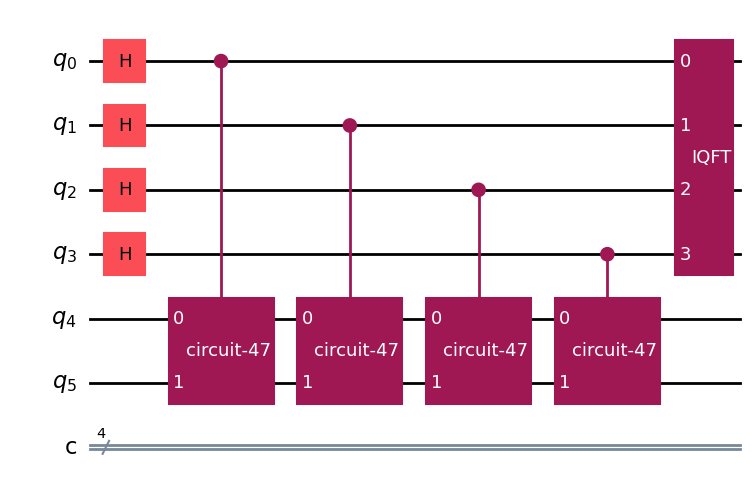

In [8]:
# `mpl` 형식으로 회로 그리기 (아직 측정 없음)
qc.draw('mpl')
plt.show()

In [9]:
# 상태벡터 시뮬레이션 (측정 전)
state = Statevector.from_instruction(qc)

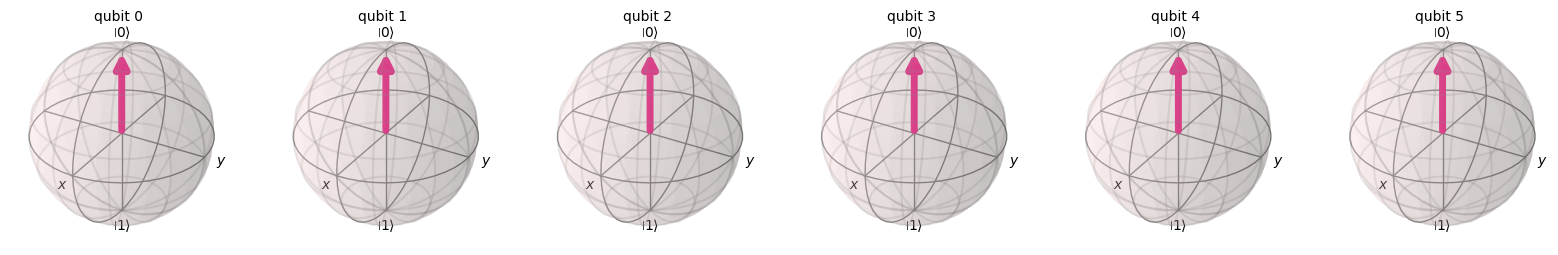

In [10]:
# 블로흐 다중벡터 그리기
plot_bloch_multivector(state)
plt.show()

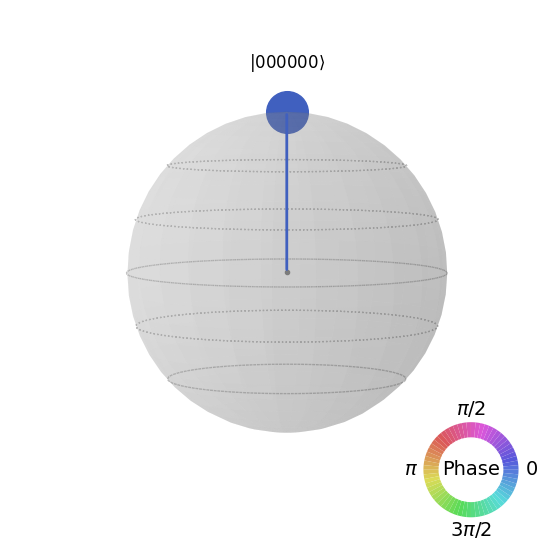

In [11]:
# QSphere 그리기
plot_state_qsphere(state)
plt.show()

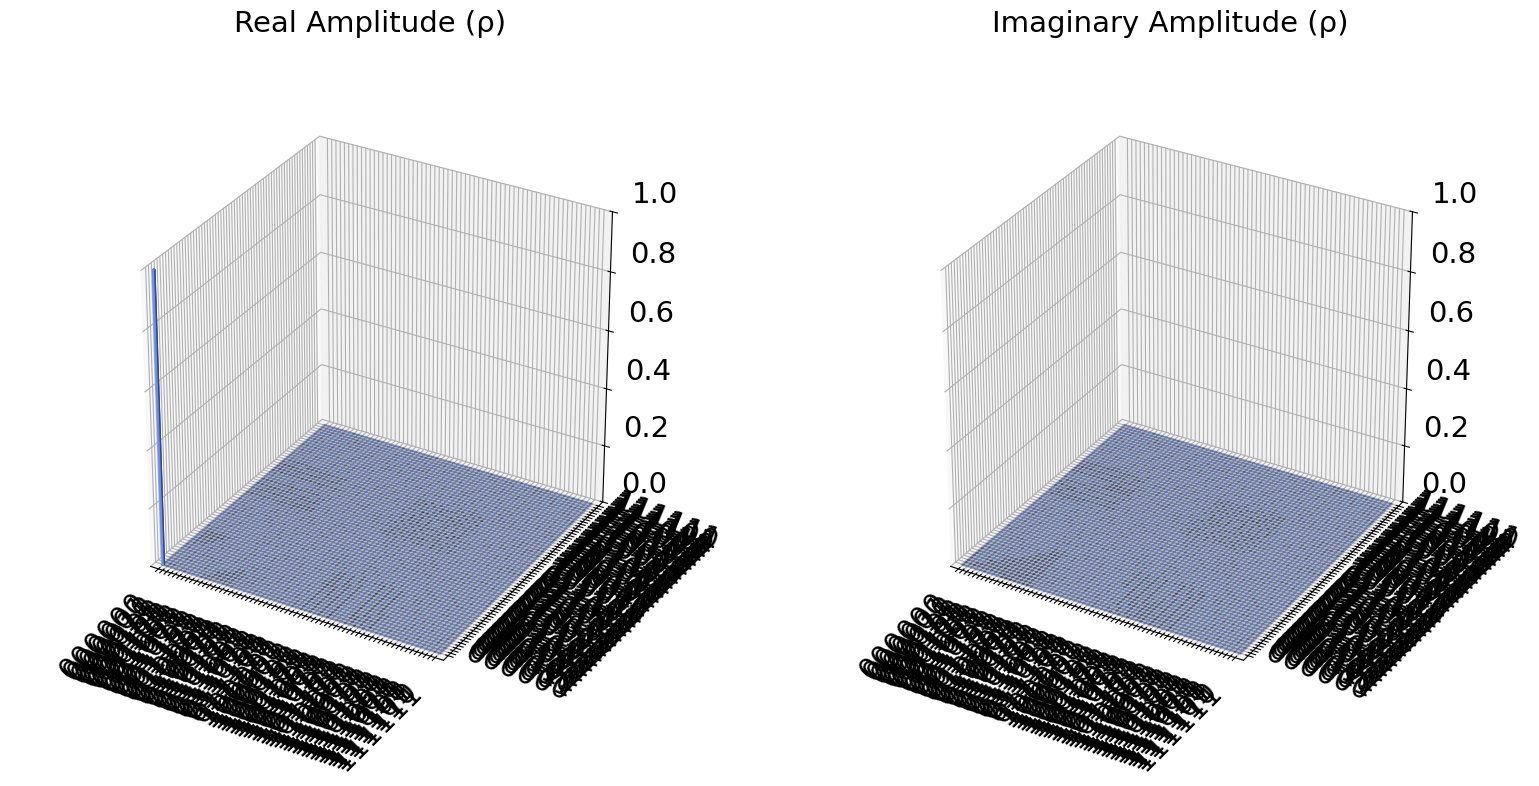

In [12]:
# State City 그리기
plot_state_city(state)
plt.show()

In [13]:
# 부분 대각합 계산 및 시각화 (특정 큐비트에 집중)
rho = partial_trace(state, [0, 1])  # 다른 큐비트를 추적 제거하고 큐비트 0,1에 집중

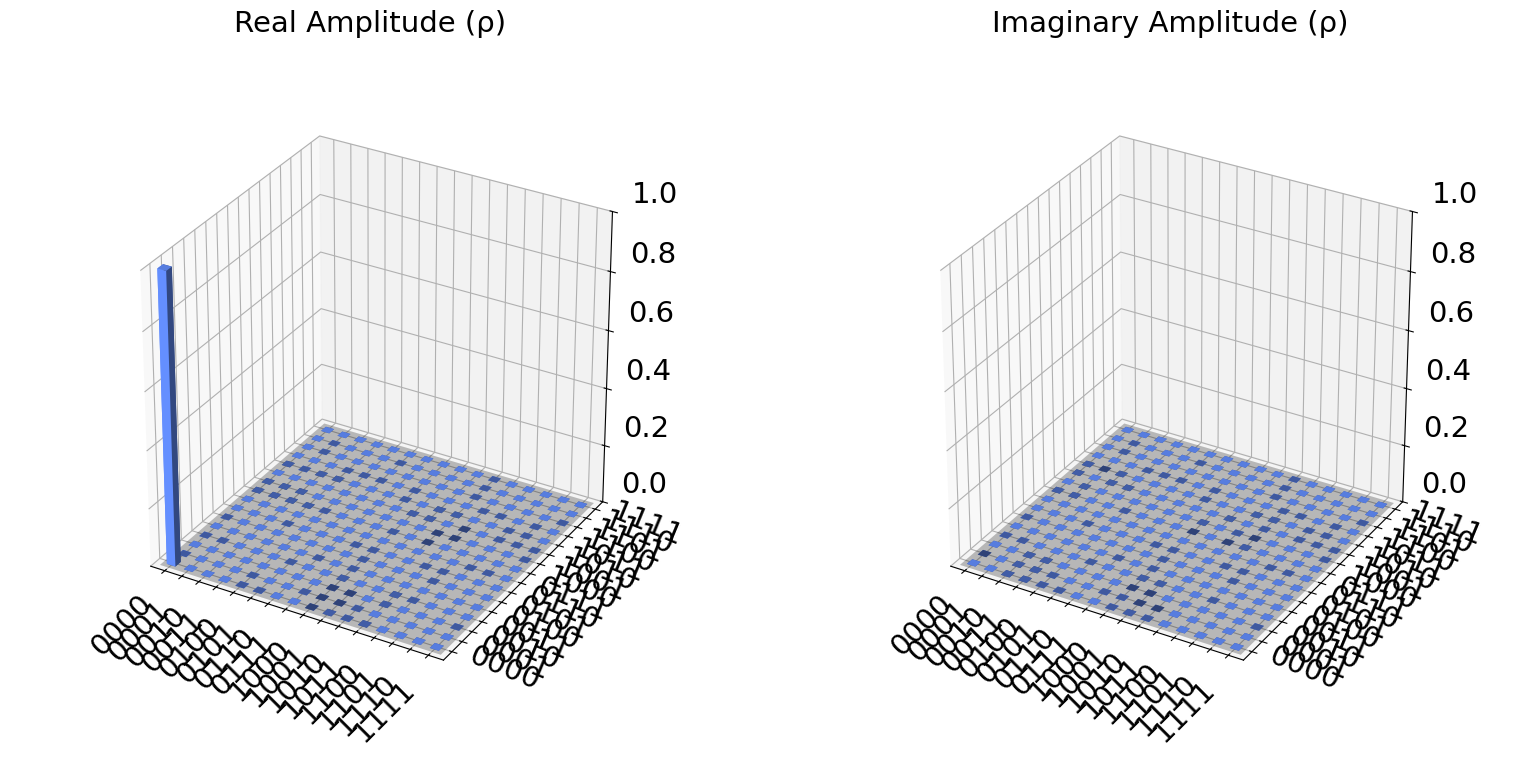

In [14]:
# 부분 대각합을 State City 형식으로 그리기
plot_state_city(rho)
plt.show()

In [15]:
# 이제 원본 회로에 측정 게이트 추가
qc.measure(range(n_qubits), range(n_qubits))

In [16]:
# AerSimulator로 회로 시뮬레이션 (측정 결과용)
simulator = AerSimulator()

In [17]:
# 회로 실행 및 결과 획득
transpiled_circtuit = transpile(qc, backend=simulator)
job = simulator.run(transpiled_circtuit, shots=1000)
result = job.result()

In [18]:
# 측정 결과 획득
counts = result.get_counts(qc)

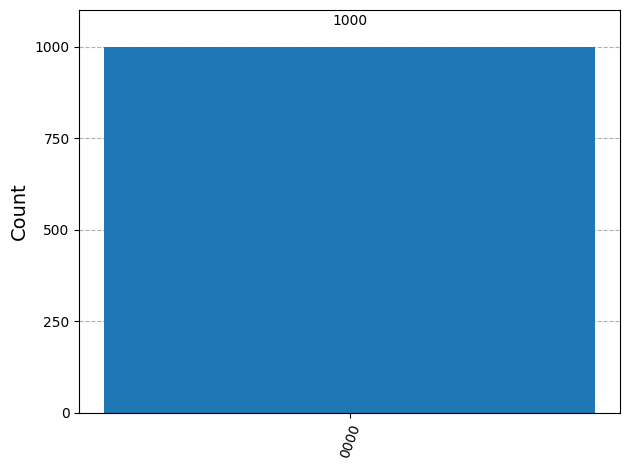

In [19]:
# 측정 히스토그램 그리기
plot_histogram(counts)
plt.show()